# 基于常数参数 $a$ 的椭圆型 PDE 与 Batch SVD 降阶模型实验（500 训练集 / 20 测试集）

本程序致力于为参数化偏微分方程（PDE）构建降阶模型（Reduced Order Model, ROM），最终提供能够用于论文撰写的仿真结果。核心研究目标包含：

1. **离线阶段（Offline Phase）耗时与基函数构造**：通过模拟生成 500 个不同参数 $a$ 对应的全阶有限元解答作为“快照矩阵（Snapshot Matrix）”，并统计利用传统的 Standard SVD（Batch SVD）进行快照空间压缩、提取“缩减基（Reduced Basis）”的时间开销与能量衰减特性。
2. **在线阶段（Online Phase）精度验证与误差分析**：选取 20 个未知的常数参数 $a$ 作为测试样本，将离线阶段构造的“缩减基”应用于基于 Galerkin 投影的降阶计算；同时结合该偏微分方程系统的解析解，从 $L^2$ 范数和 $H^1$ 范数等多个视角，量化降阶模型的绝对误差与相对误差。

---

## 一、 数学物理模型与实验对象

本实验考量二维空间区域 $\Omega=(0,1)^2$ 内带有齐次边值条件的稳态椭圆型方程（常由达西定律或稳态热传导导出）：

$$
\begin{cases}
-\nabla \cdot (a \nabla u) = f, & \text{in } \Omega \\
u = 0, & \text{on } \partial\Omega
\end{cases}
$$

其中，扩散系数或传导率 $a$ 为可变的**常数标量参数**。为了精准评测模型降阶方法的严密性和截断误差，通过选取事先已知的解析解（Manufactured Solution）：

$$
 u_{\mathrm{exact}}(x,y) = x(1-x)y(1-y)
$$

借由反求机制，可唯一确定任意参数 $a$ 对应的右端源项分布：

$$
 f(x,y;a) = -\nabla\cdot(a\nabla u_{\mathrm{exact}}) = a \cdot 2\big( x(1-x) + y(1-y) \big)
$$

### 核心论点优势
由于对于所有的参数 $a$，右端项 $f$ 取决于 $a$ 的线性变化，其内在的变分问题具有极强的同源性。这决定了由参数引发的流形空间天然具备**极端低秩**的数学特性。这不仅极其契合 Reduced Basis Method 大幅削减自由度（Degrees of Freedom，DoF）的初衷，同时也极其方便后期在控制变量基础上对比探讨 Incremental SVD（增量 SVD）相较于 Batch SVD 的运算效率跳跃与内存利用优势。

In [19]:

%matplotlib inline

import os
import time
from math import sqrt

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [20]:
try:
    from ngsolve import *
    from netgen.geom2d import unit_square
    print("NGSolve / Netgen import success.")
except Exception as e:
    raise ImportError(
        "无法导入 NGSolve / Netgen，请确认 notebook 内核和终端运行脚本时使用的是同一个环境。\n"
        f"原始错误: {e}"
    )


NGSolve / Netgen import success.



## 参数配置

下面的配置已经按你当前要求固定成：

- 训练集 500 个参数
- 测试集 20 个参数
- $a$ 是区间 $[0.5,2.0]$ 上的常数标量参数
- 重点统计：
  - 训练快照生成时间
  - batch SVD 时间
  - 整个程序总时间


In [21]:

ORDER = 2
MESH_H = 0.1

A_MIN = 0.5
A_MAX = 2.0
NUM_TRAIN = 500
NUM_TEST = 20
RANDOM_SEED = 42

USE_ENERGY_RANK = True
ENERGY_THRESHOLD = 0.999999
FIXED_RANK = 5
MAX_RANK_SWEEP = 10
TEST_VIS_INDEX = 0

PLOT_DIR = "plots_batch_svd_constant_a_train500_test20"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"PLOT_DIR = {PLOT_DIR}")
print(f"train samples = {NUM_TRAIN}, test samples = {NUM_TEST}")
print(f"a range = [{A_MIN}, {A_MAX}]")


PLOT_DIR = plots_batch_svd_constant_a_train500_test20
train samples = 500, test samples = 20
a range = [0.5, 2.0]



## PDE 定义

使用解析解

$$
 u_{\mathrm{exact}}(x,y)=x(1-x)y(1-y).
$$

对应右端项是

$$
 f(x,y;a)=a\cdot 2\big(x(1-x)+y(1-y)\big).
$$


In [22]:

u_exact_cf = x * (1 - x) * y * (1 - y)


def rhs_from_a(a_val):
    return float(a_val) * 2 * (x * (1 - x) + y * (1 - y))



## Full-order 求解器与 Batch SVD ROM

这里先保证两件事稳定：

1. **训练集能正常生成快照矩阵**；
2. **测试集能基于训练基做降阶求解，并和精确解比较**。

为了避开你前面遇到的两个坑，这里做了两点处理：

- 不在 `__init__` 里立刻把 NGSolve 矩阵转成 numpy，避免初始化阶段报错；
- 不用 `grad(gfu)` 直接算测试误差，而是用离散矩阵范数

$$
\|e\|_{L^2,h}^2 = e^T M e,
\qquad
\|e\|_{H^1,h}^2 = e^T(M+K)e.
$$


In [23]:

class BatchSVDEllipticROM:
    def __init__(self, mesh, order=2):
        self.mesh = mesh
        self.order = order
        self.fes = H1(mesh, order=order, dirichlet=".*")
        self.ndof = self.fes.ndof

        self.u = self.fes.TrialFunction()
        self.v = self.fes.TestFunction()

        self._dense_ready = False
        self.mass_np = None
        self.stiffness_np = None
        self.h1_np = None
        self.f_ref_np = None

    def solve_single(self, a_val):
        a_float = float(a_val)

        bilinear = BilinearForm(self.fes, symmetric=True)
        bilinear += a_float * grad(self.u) * grad(self.v) * dx

        linear = LinearForm(self.fes)
        linear += rhs_from_a(a_float) * self.v * dx

        t0 = time.perf_counter()
        bilinear.Assemble()
        linear.Assemble()

        gfu = GridFunction(self.fes)
        inv = bilinear.mat.Inverse(self.fes.FreeDofs(), inverse="sparsecholesky")
        gfu.vec.data = inv * linear.vec
        solve_time = time.perf_counter() - t0

        vec = gfu.vec.FV().NumPy().copy()
        return {
            "a": a_float,
            "gfu": gfu,
            "vector": vec,
            "solve_time": solve_time,
        }

    def exact_gridfunction(self):
        gfu = GridFunction(self.fes)
        gfu.Set(u_exact_cf)
        return gfu

    def vector_to_gridfunction(self, vec):
        gfu = GridFunction(self.fes)
        gfu.vec.FV().NumPy()[:] = vec
        return gfu

    def _ngsolve_matrix_to_numpy(self, mat):
        n = self.ndof
        dense = np.zeros((n, n), dtype=float)

        gf_template = GridFunction(self.fes)
        ej = gf_template.vec.CreateVector()
        y = gf_template.vec.CreateVector()

        for j in range(n):
            ej[:] = 0.0
            ej.FV().NumPy()[j] = 1.0
            y.data = mat * ej
            dense[:, j] = y.FV().NumPy()

        return dense



    def _assemble_dense_operators(self):
        if self._dense_ready:
            return

        mform = BilinearForm(self.fes, symmetric=True)
        mform += self.u * self.v * dx
        mform.Assemble()

        kform = BilinearForm(self.fes, symmetric=True)
        kform += grad(self.u) * grad(self.v) * dx
        kform.Assemble()

        lform = LinearForm(self.fes)
        lform += rhs_from_a(1.0) * self.v * dx
        lform.Assemble()

        self.mass_np = self._ngsolve_matrix_to_numpy(mform.mat)
        self.stiffness_np = self._ngsolve_matrix_to_numpy(kform.mat)
        self.h1_np = self.mass_np + self.stiffness_np
        self.f_ref_np = lform.vec.FV().NumPy().copy()
        self._dense_ready = True

    def reduced_solve(self, a_val, Phi):
        self._assemble_dense_operators()

        a_float = float(a_val)
        A_np = a_float * self.stiffness_np
        f_np = a_float * self.f_ref_np

        Ar = Phi.T @ A_np @ Phi
        fr = Phi.T @ f_np
        coeff = np.linalg.solve(Ar, fr)
        u_red = Phi @ coeff
        return coeff, u_red

    def relative_discrete_errors_against_exact(self, vec_approx, vec_exact):
        self._assemble_dense_operators()
        err = vec_approx - vec_exact

        l2_num = float(err.T @ self.mass_np @ err)
        l2_den = float(vec_exact.T @ self.mass_np @ vec_exact)

        h1_num = float(err.T @ self.h1_np @ err)
        h1_den = float(vec_exact.T @ self.h1_np @ vec_exact)

        l2_rel = sqrt(max(l2_num, 0.0) / max(l2_den, 1e-30))
        h1_rel = sqrt(max(h1_num, 0.0) / max(h1_den, 1e-30))
        return l2_rel, h1_rel



## 构造网格与 ROM 对象

这一步只做最基本的网格与有限元空间初始化，不在这里做 dense 矩阵转换，避免初始化阶段就报错。


In [24]:

t_program_start = time.perf_counter()

mesh = Mesh(unit_square.GenerateMesh(maxh=MESH_H))
rom = BatchSVDEllipticROM(mesh, order=ORDER)

n_elements = mesh.ne if hasattr(mesh, "ne") else mesh.ngmesh.ne
print(f"mesh elements = {n_elements}, ndof = {rom.ndof}")


mesh elements = 230, ndof = 501



## 训练参数与测试参数

- 训练集：500 个参数，均匀取样；
- 测试集：20 个新参数，随机取样但固定随机种子。


In [25]:

rng = np.random.default_rng(RANDOM_SEED)
train_a = np.linspace(A_MIN, A_MAX, NUM_TRAIN)
test_a = np.sort(rng.uniform(A_MIN, A_MAX, size=NUM_TEST))

print(f"train_a shape = {train_a.shape}")
print(f"test_a shape = {test_a.shape}")
print(f"train range = ({train_a.min():.6f}, {train_a.max():.6f})")
print(f"test range = ({test_a.min():.6f}, {test_a.max():.6f})")


train_a shape = (500,)
test_a shape = (20,)
train range = (0.500000, 2.000000)
test range = (0.595726, 1.963434)



## 训练阶段：生成快照矩阵

快照矩阵记为

$$
S_{\mathrm{train}} = [u_h(a_1),u_h(a_2),\ldots,u_h(a_{500})] \in \mathbb{R}^{N\times 500}.
$$

这一部分的耗时就是 **训练样本 full-order 求解时间**。


In [26]:

train_results = []
train_snapshots = []

t_train_solve_start = time.perf_counter()
for a_val in tqdm(train_a, desc="Training full-order solves"):
    out = rom.solve_single(a_val)
    train_results.append(out)
    train_snapshots.append(out["vector"])
train_solve_time = time.perf_counter() - t_train_solve_start

train_snapshot_matrix = np.column_stack(train_snapshots)
train_solve_times = np.array([r["solve_time"] for r in train_results], dtype=float)

print(f"train_snapshot_matrix shape = {train_snapshot_matrix.shape}")
print(f"training full-order total time = {train_solve_time:.6f} s")
print(f"mean training single solve time = {train_solve_times.mean():.6f} s")


Training full-order solves: 100%|██████████| 500/500 [00:01<00:00, 389.78it/s]

train_snapshot_matrix shape = (501, 500)
training full-order total time = 1.284188 s
mean training single solve time = 0.002419 s



## 训练阶段：Batch SVD

对训练快照矩阵做标准 SVD：

$$
S_{\mathrm{train}} = U\Sigma V^T.
$$

取前 $r$ 个左奇异向量构成训练基

$$
\Phi = U_{(:,1:r)}.
$$


In [27]:

t_svd_start = time.perf_counter()
U, s, VT = np.linalg.svd(train_snapshot_matrix, full_matrices=False)
svd_build_time = time.perf_counter() - t_svd_start

energy = np.cumsum(s**2) / np.sum(s**2)
rank_energy = int(np.searchsorted(energy, ENERGY_THRESHOLD) + 1)
rank_used = rank_energy if USE_ENERGY_RANK else min(FIXED_RANK, len(s))
rank_used = max(1, min(rank_used, len(s)))

Phi = U[:, :rank_used]
train_total_time = train_solve_time + svd_build_time

print(f"SVD build time = {svd_build_time:.6f} s")
print(f"rank from energy threshold = {rank_energy}")
print(f"rank used = {rank_used}")
print(f"training total time = {train_total_time:.6f} s")


SVD build time = 0.023874 s
rank from energy threshold = 1
rank used = 1
training total time = 1.308061 s



## 测试阶段：用训练基做降阶求解，并与精确解比较

对每个测试参数 $a_{\mathrm{test}}$：

1. 使用训练基 $\Phi$ 做 reduced Galerkin 求解；
2. 把降阶解向量记为 $u_r$；
3. 把精确解插值到有限元空间，得到离散真值向量 $u_{\mathrm{exact},h}$；
4. 计算向量误差、相对 $L^2$ 误差和相对 $H^1$ 误差。

这里的降阶系统是

$$
(\Phi^T A(a)\Phi)c = \Phi^T f(a),
\qquad
u_r = \Phi c.
$$


In [28]:

exact_gfu = rom.exact_gridfunction()
exact_vec = exact_gfu.vec.FV().NumPy().copy()


def relative_vector_error(vec_true, vec_approx):
    denom = np.linalg.norm(vec_true)
    if denom == 0:
        return 0.0
    return np.linalg.norm(vec_true - vec_approx) / denom


test_results = []
test_vectors = []

t_test_start = time.perf_counter()
for a_val in tqdm(test_a, desc="Testing reduced solves"):
    t0 = time.perf_counter()
    coeff, vec_red = rom.reduced_solve(a_val, Phi)
    red_time = time.perf_counter() - t0

    vec_rel_err = relative_vector_error(exact_vec, vec_red)
    l2_rel_err, h1_rel_err = rom.relative_discrete_errors_against_exact(vec_red, exact_vec)

    test_results.append({
        "a": float(a_val),
        "reduced_solve_time": red_time,
        "vector_rel_error": vec_rel_err,
        "l2_rel_error": l2_rel_err,
        "h1_rel_error": h1_rel_err,
    })
    test_vectors.append(vec_red)

test_total_time = time.perf_counter() - t_test_start
program_total_time = time.perf_counter() - t_program_start

test_red_times = np.array([r["reduced_solve_time"] for r in test_results], dtype=float)
test_vec_errors = np.array([r["vector_rel_error"] for r in test_results], dtype=float)
test_l2_errors = np.array([r["l2_rel_error"] for r in test_results], dtype=float)
test_h1_errors = np.array([r["h1_rel_error"] for r in test_results], dtype=float)

print(f"test total time = {test_total_time:.6f} s")
print(f"mean reduced solve time = {test_red_times.mean():.6f} s")
print(f"mean test vector relative error = {test_vec_errors.mean():.6e}")
print(f"mean test L2 relative error = {test_l2_errors.mean():.6e}")
print(f"mean test H1 relative error = {test_h1_errors.mean():.6e}")
print(f"program total time = {program_total_time:.6f} s")


Testing reduced solves: 100%|██████████| 20/20 [00:00<00:00, 709.01it/s]

test total time = 0.029576 s
mean reduced solve time = 0.001157 s
mean test vector relative error = 3.213231e-03
mean test L2 relative error = 1.139314e-04
mean test H1 relative error = 1.302764e-03
program total time = 1.373681 s



## 结果汇总


In [29]:

summary = {
    "ndof": rom.ndof,
    "num_train": NUM_TRAIN,
    "num_test": NUM_TEST,
    "rank_used": rank_used,
    "train_snapshot_total_time_s": train_solve_time,
    "svd_build_time_s": svd_build_time,
    "train_total_time_s": train_total_time,
    "test_total_time_s": test_total_time,
    "program_total_time_s": program_total_time,
    "mean_train_single_solve_time_s": float(train_solve_times.mean()),
    "mean_test_reduced_solve_time_s": float(test_red_times.mean()),
    "mean_test_vector_rel_error": float(test_vec_errors.mean()),
    "mean_test_l2_rel_error": float(test_l2_errors.mean()),
    "mean_test_h1_rel_error": float(test_h1_errors.mean()),
}

for k, v in summary.items():
    print(f"{k}: {v}")


ndof: 501
num_train: 500
num_test: 20
rank_used: 1
train_snapshot_total_time_s: 1.2841876019992924
svd_build_time_s: 0.02387351800007309
train_total_time_s: 1.3080611199993655
test_total_time_s: 0.029576263000308245
program_total_time_s: 1.3736812689994622
mean_train_single_solve_time_s: 0.0024187412859992038
mean_test_reduced_solve_time_s: 0.0011572742499993184
mean_test_vector_rel_error: 0.0032132310346974975
mean_test_l2_rel_error: 0.00011393143080842079
mean_test_h1_rel_error: 0.0013027644841296163


## 实验数据图表可视化（论文级绘图设置）

为了使提取的图表能够直接插入浙江大学论文模板 `zjuthesis` 并保持专业严谨的美观性，我们首先全局设置 `matplotlib` 参数，包括英文字体设为仿宋/或标准学术线型、提升图片分辨率并增加合适的图例说明。

In [30]:
# 设置论文标准的高分辨率和字体风格
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],  # 西文使用 Times New Roman 经典学术字体
    'mathtext.fontset': 'stix',         # 公式字体配套风格
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--'
})

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15421/934128556.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Singular Value $\sigma_k$ (Log Scale)", fontweight='bold')
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were

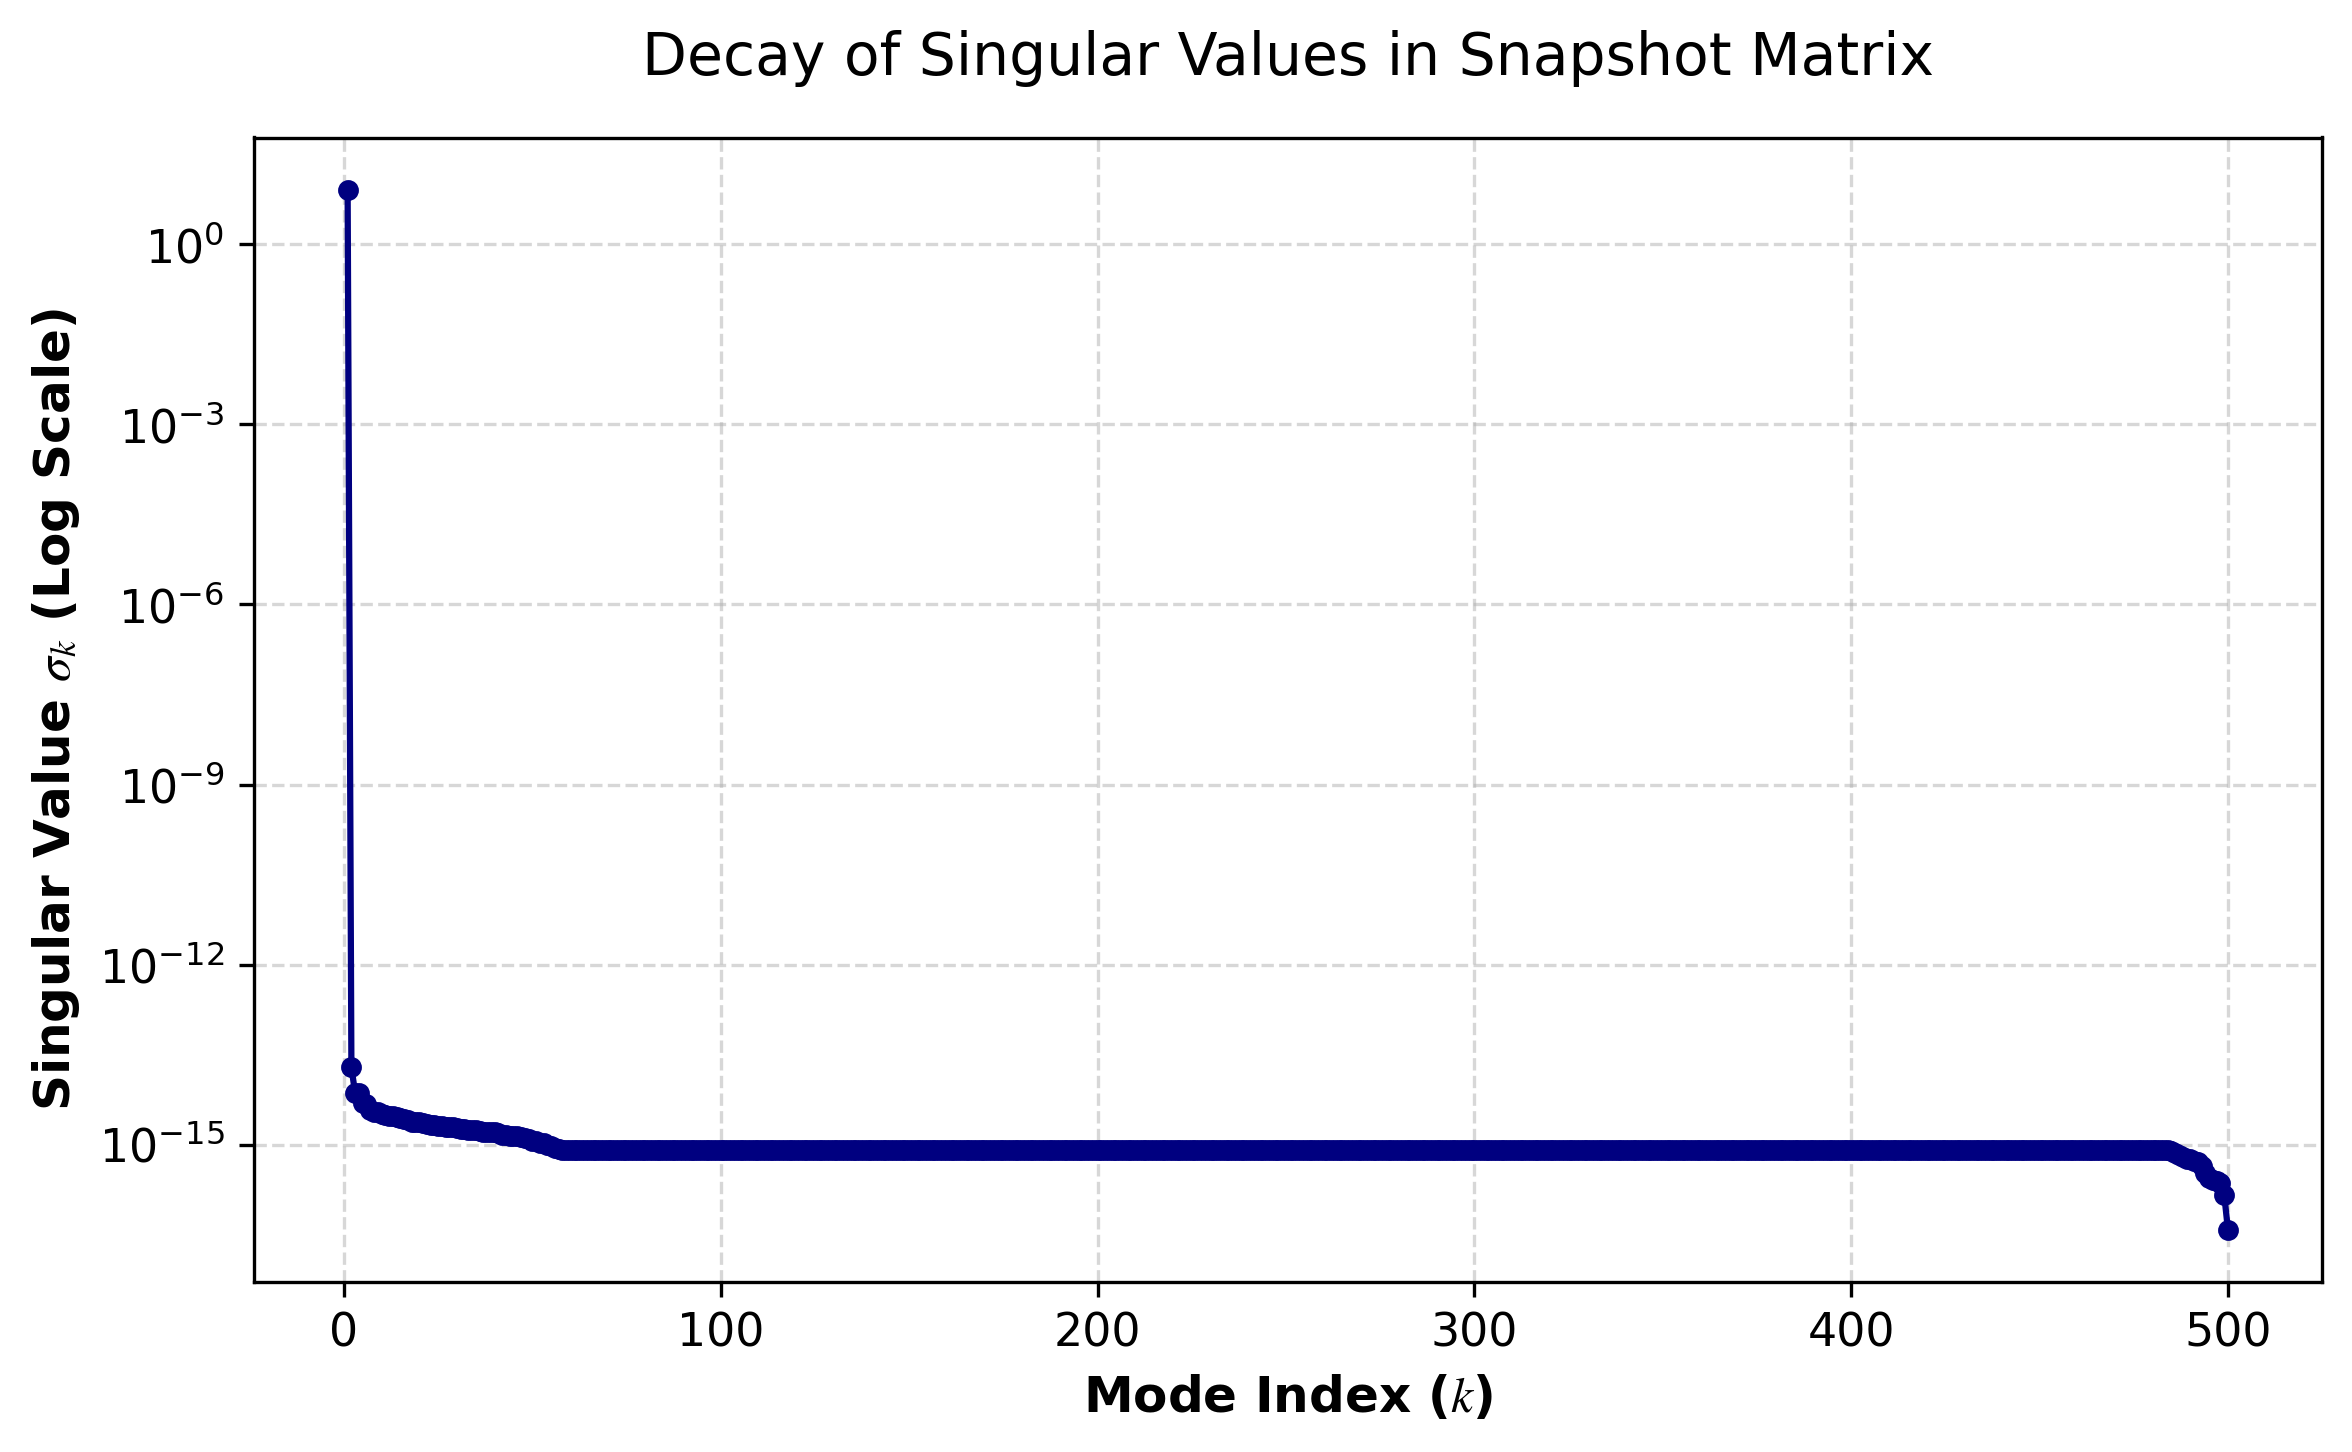

In [31]:
plt.figure(figsize=(8, 5))
plt.semilogy(np.arange(1, len(s)+1), s, marker='o', markersize=4, color='navy', linewidth=1.5)
plt.xlabel("Mode Index ($k$)", fontweight='bold')
plt.ylabel("Singular Value $\sigma_k$ (Log Scale)", fontweight='bold')
plt.title("Decay of Singular Values in Snapshot Matrix", pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "singular_values.pdf"), bbox_inches="tight")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

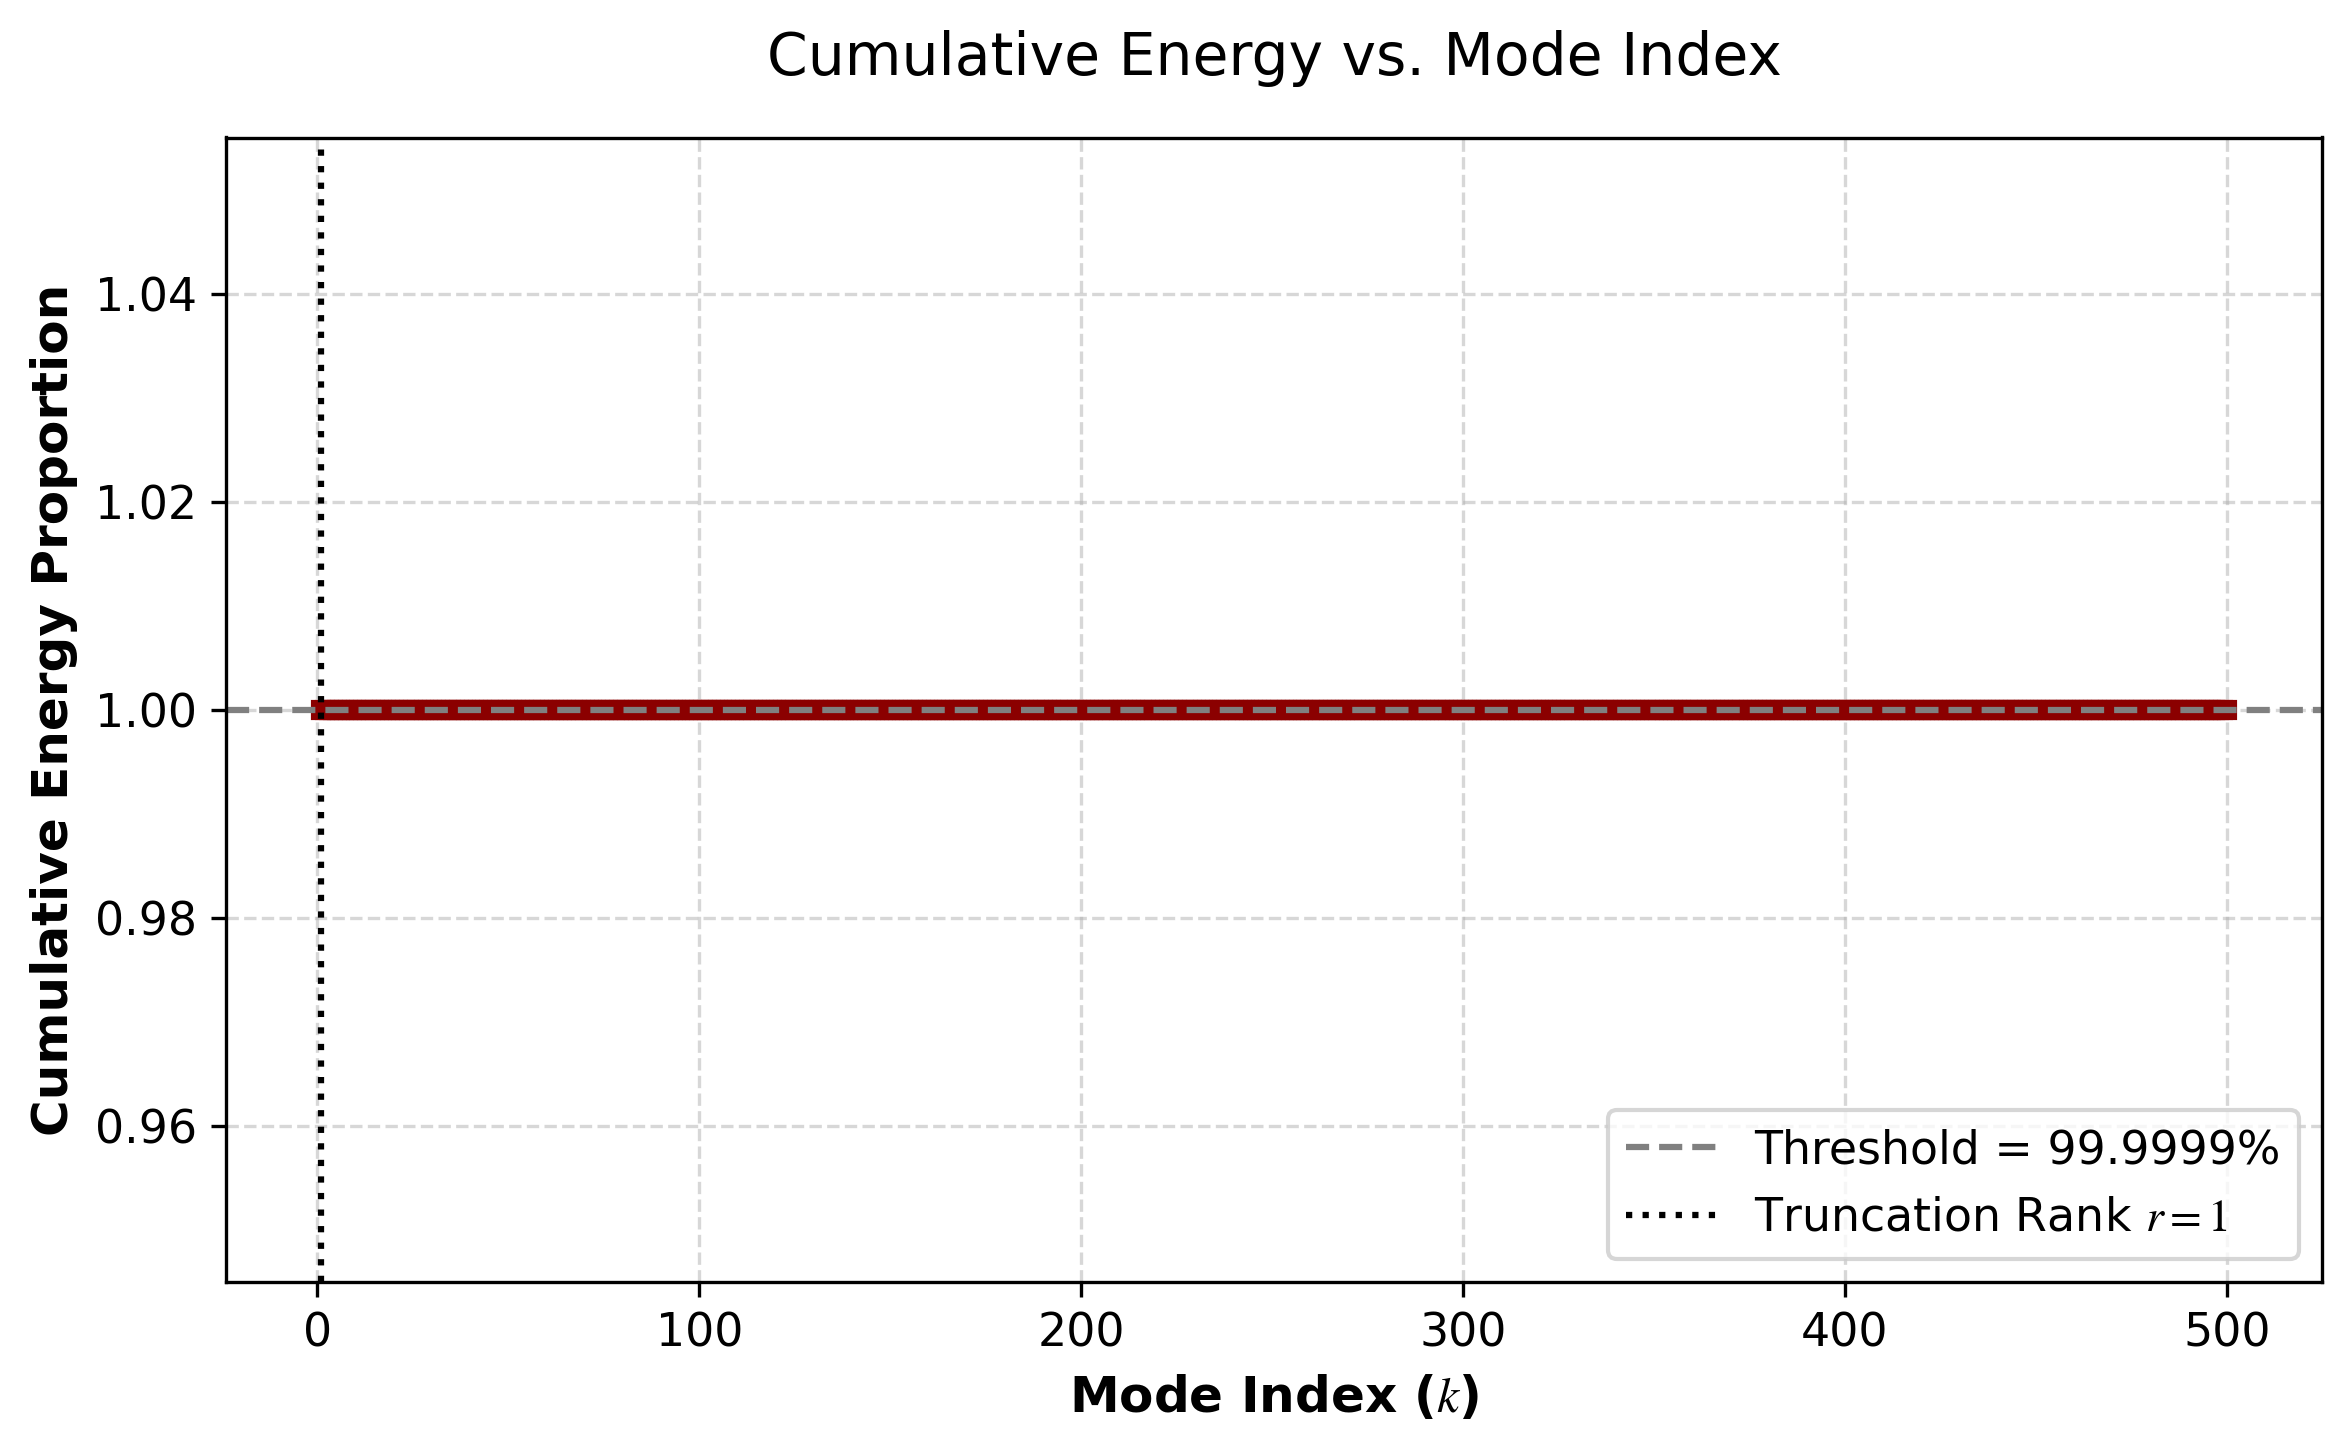

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(energy)+1), energy, marker='s', markersize=4, color='darkred', linewidth=1.5)
plt.axhline(ENERGY_THRESHOLD, linestyle='--', color='gray', label=f'Threshold = {ENERGY_THRESHOLD*100}%')
plt.axvline(rank_energy, linestyle=':', color='black', label=f'Truncation Rank $r={rank_energy}$')
plt.xlabel("Mode Index ($k$)", fontweight='bold')
plt.ylabel("Cumulative Energy Proportion", fontweight='bold')
plt.title("Cumulative Energy vs. Mode Index", pad=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "cumulative_energy.pdf"), bbox_inches="tight")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

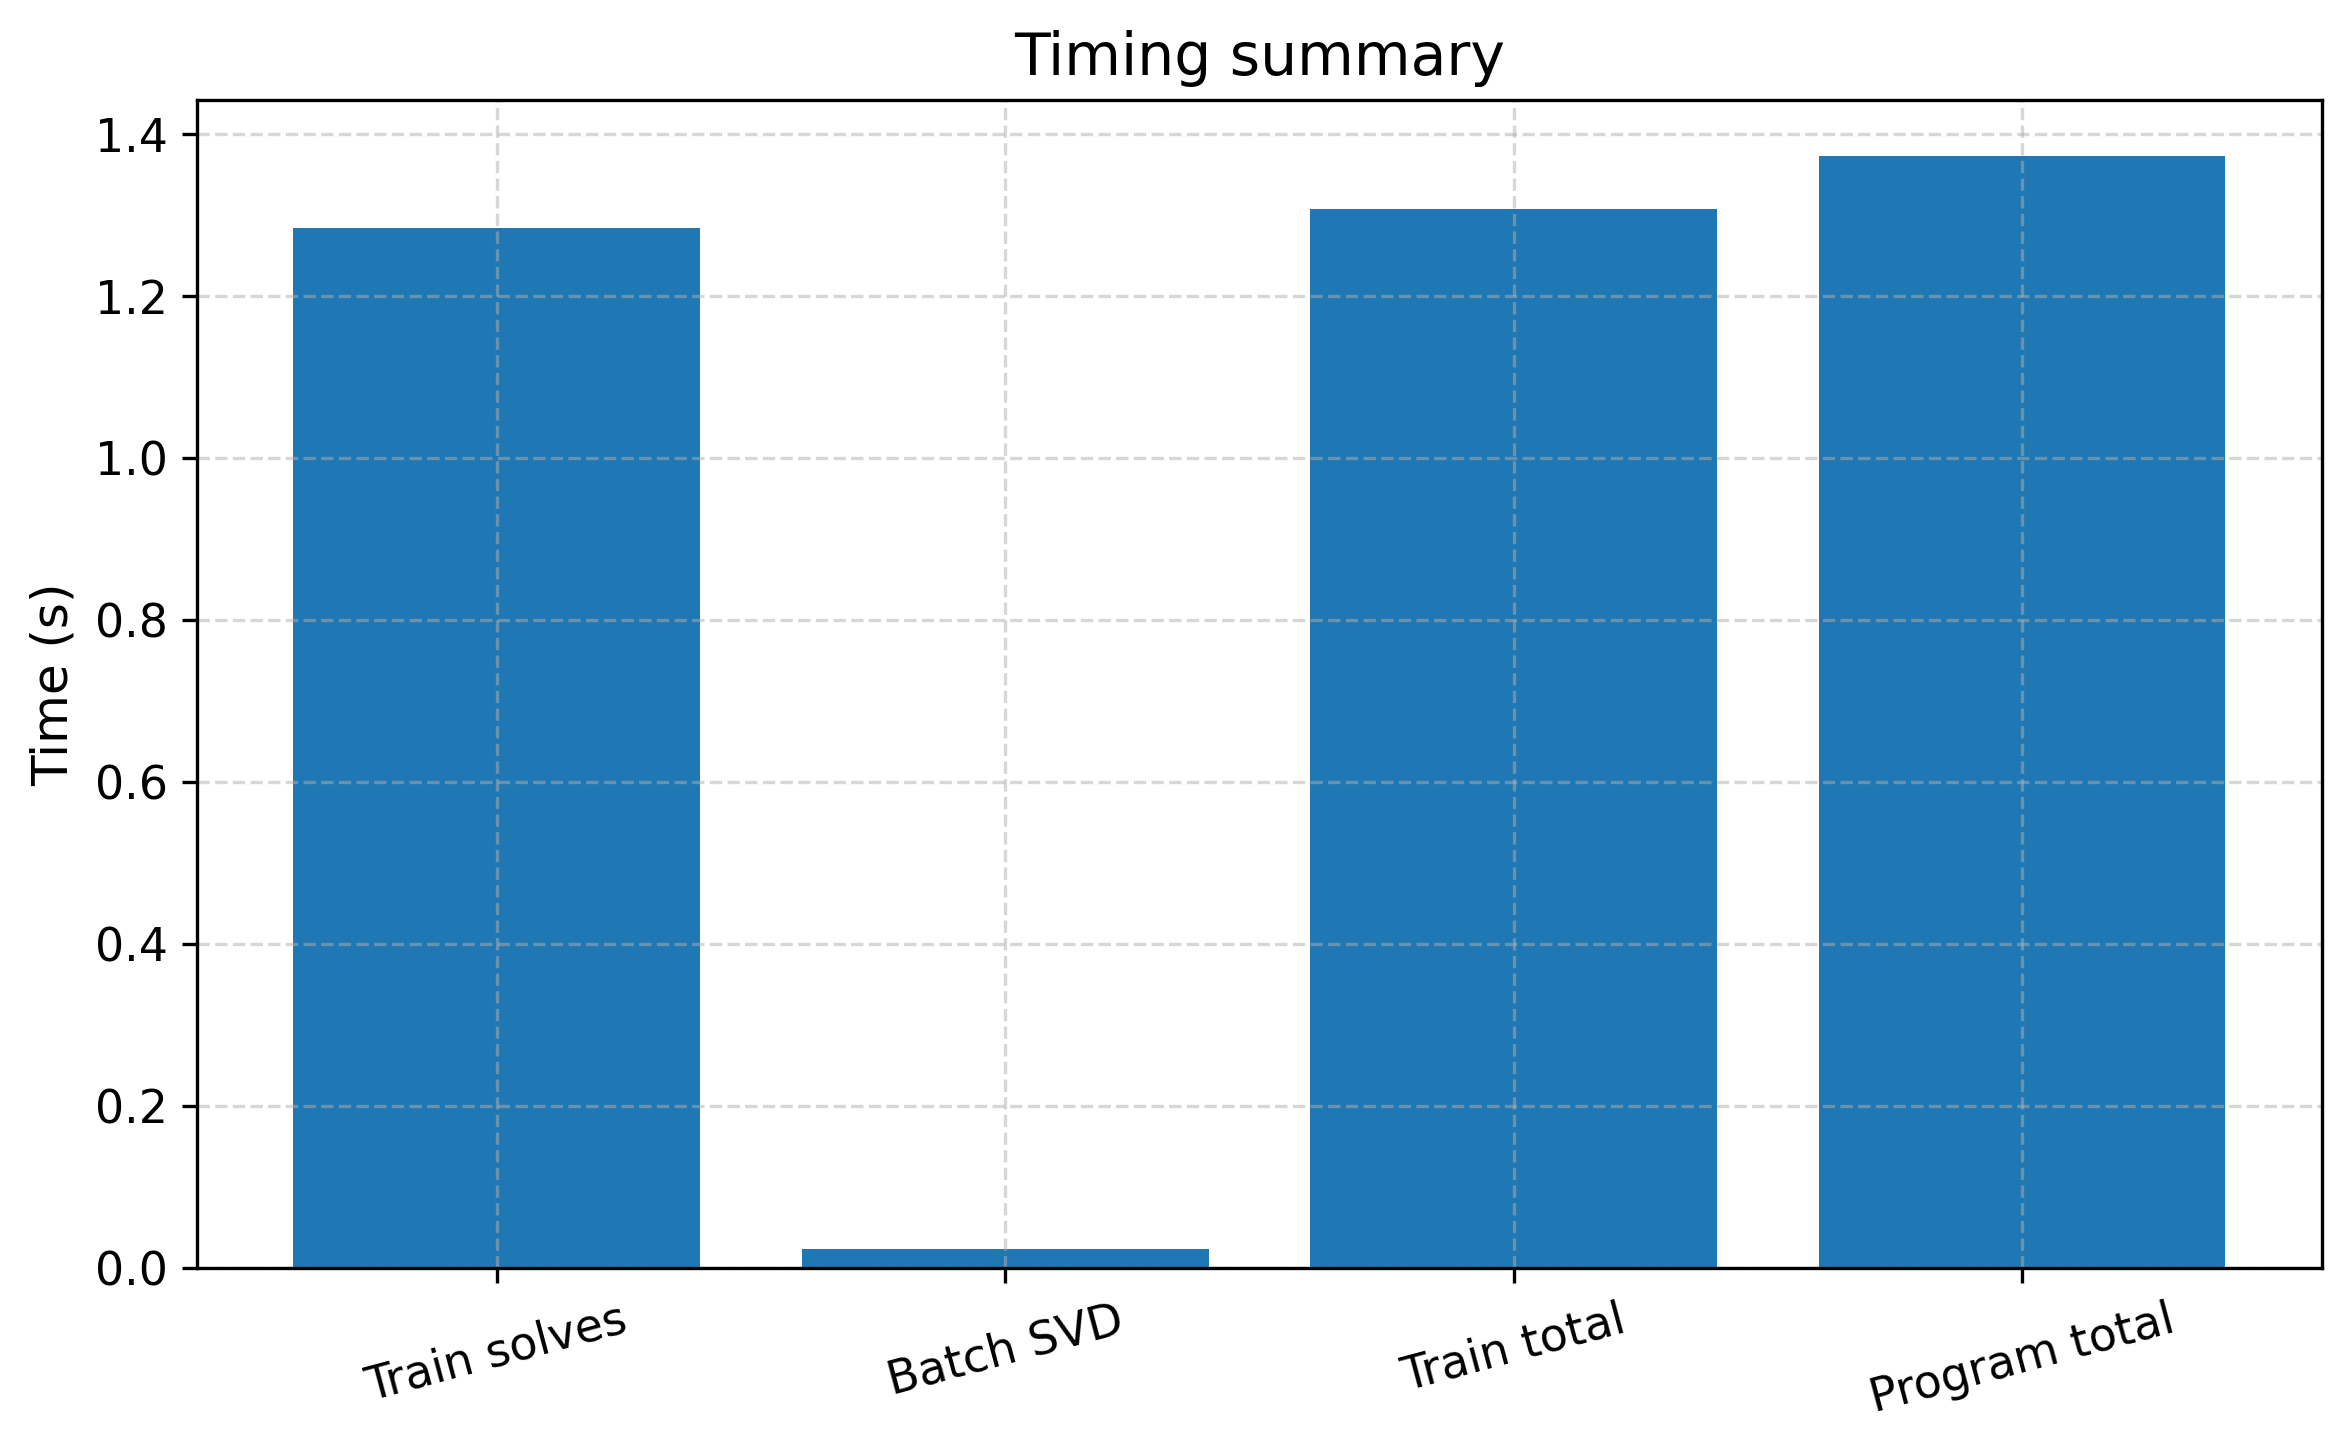

In [33]:

labels = ["Train solves", "Batch SVD", "Train total", "Program total"]
values = [train_solve_time, svd_build_time, train_total_time, program_total_time]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("Time (s)")
plt.title("Timing summary")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "timing_summary.png"), dpi=200, bbox_inches="tight")
plt.show()


<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_15421/1638574964.py:3: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(test_a, test_l2_errors, marker='s', color='tab:green', label='$L^2(\Omega)$ Rel. Error', linewidth=1.5)
/tmp/ipykernel_15421/1638574964.py:4: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(test_a, test_h1_errors, marker='^', color='tab:orange', label='$H^1(\Omega)$ Rel. Error', linewidth=1.5)
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following fa

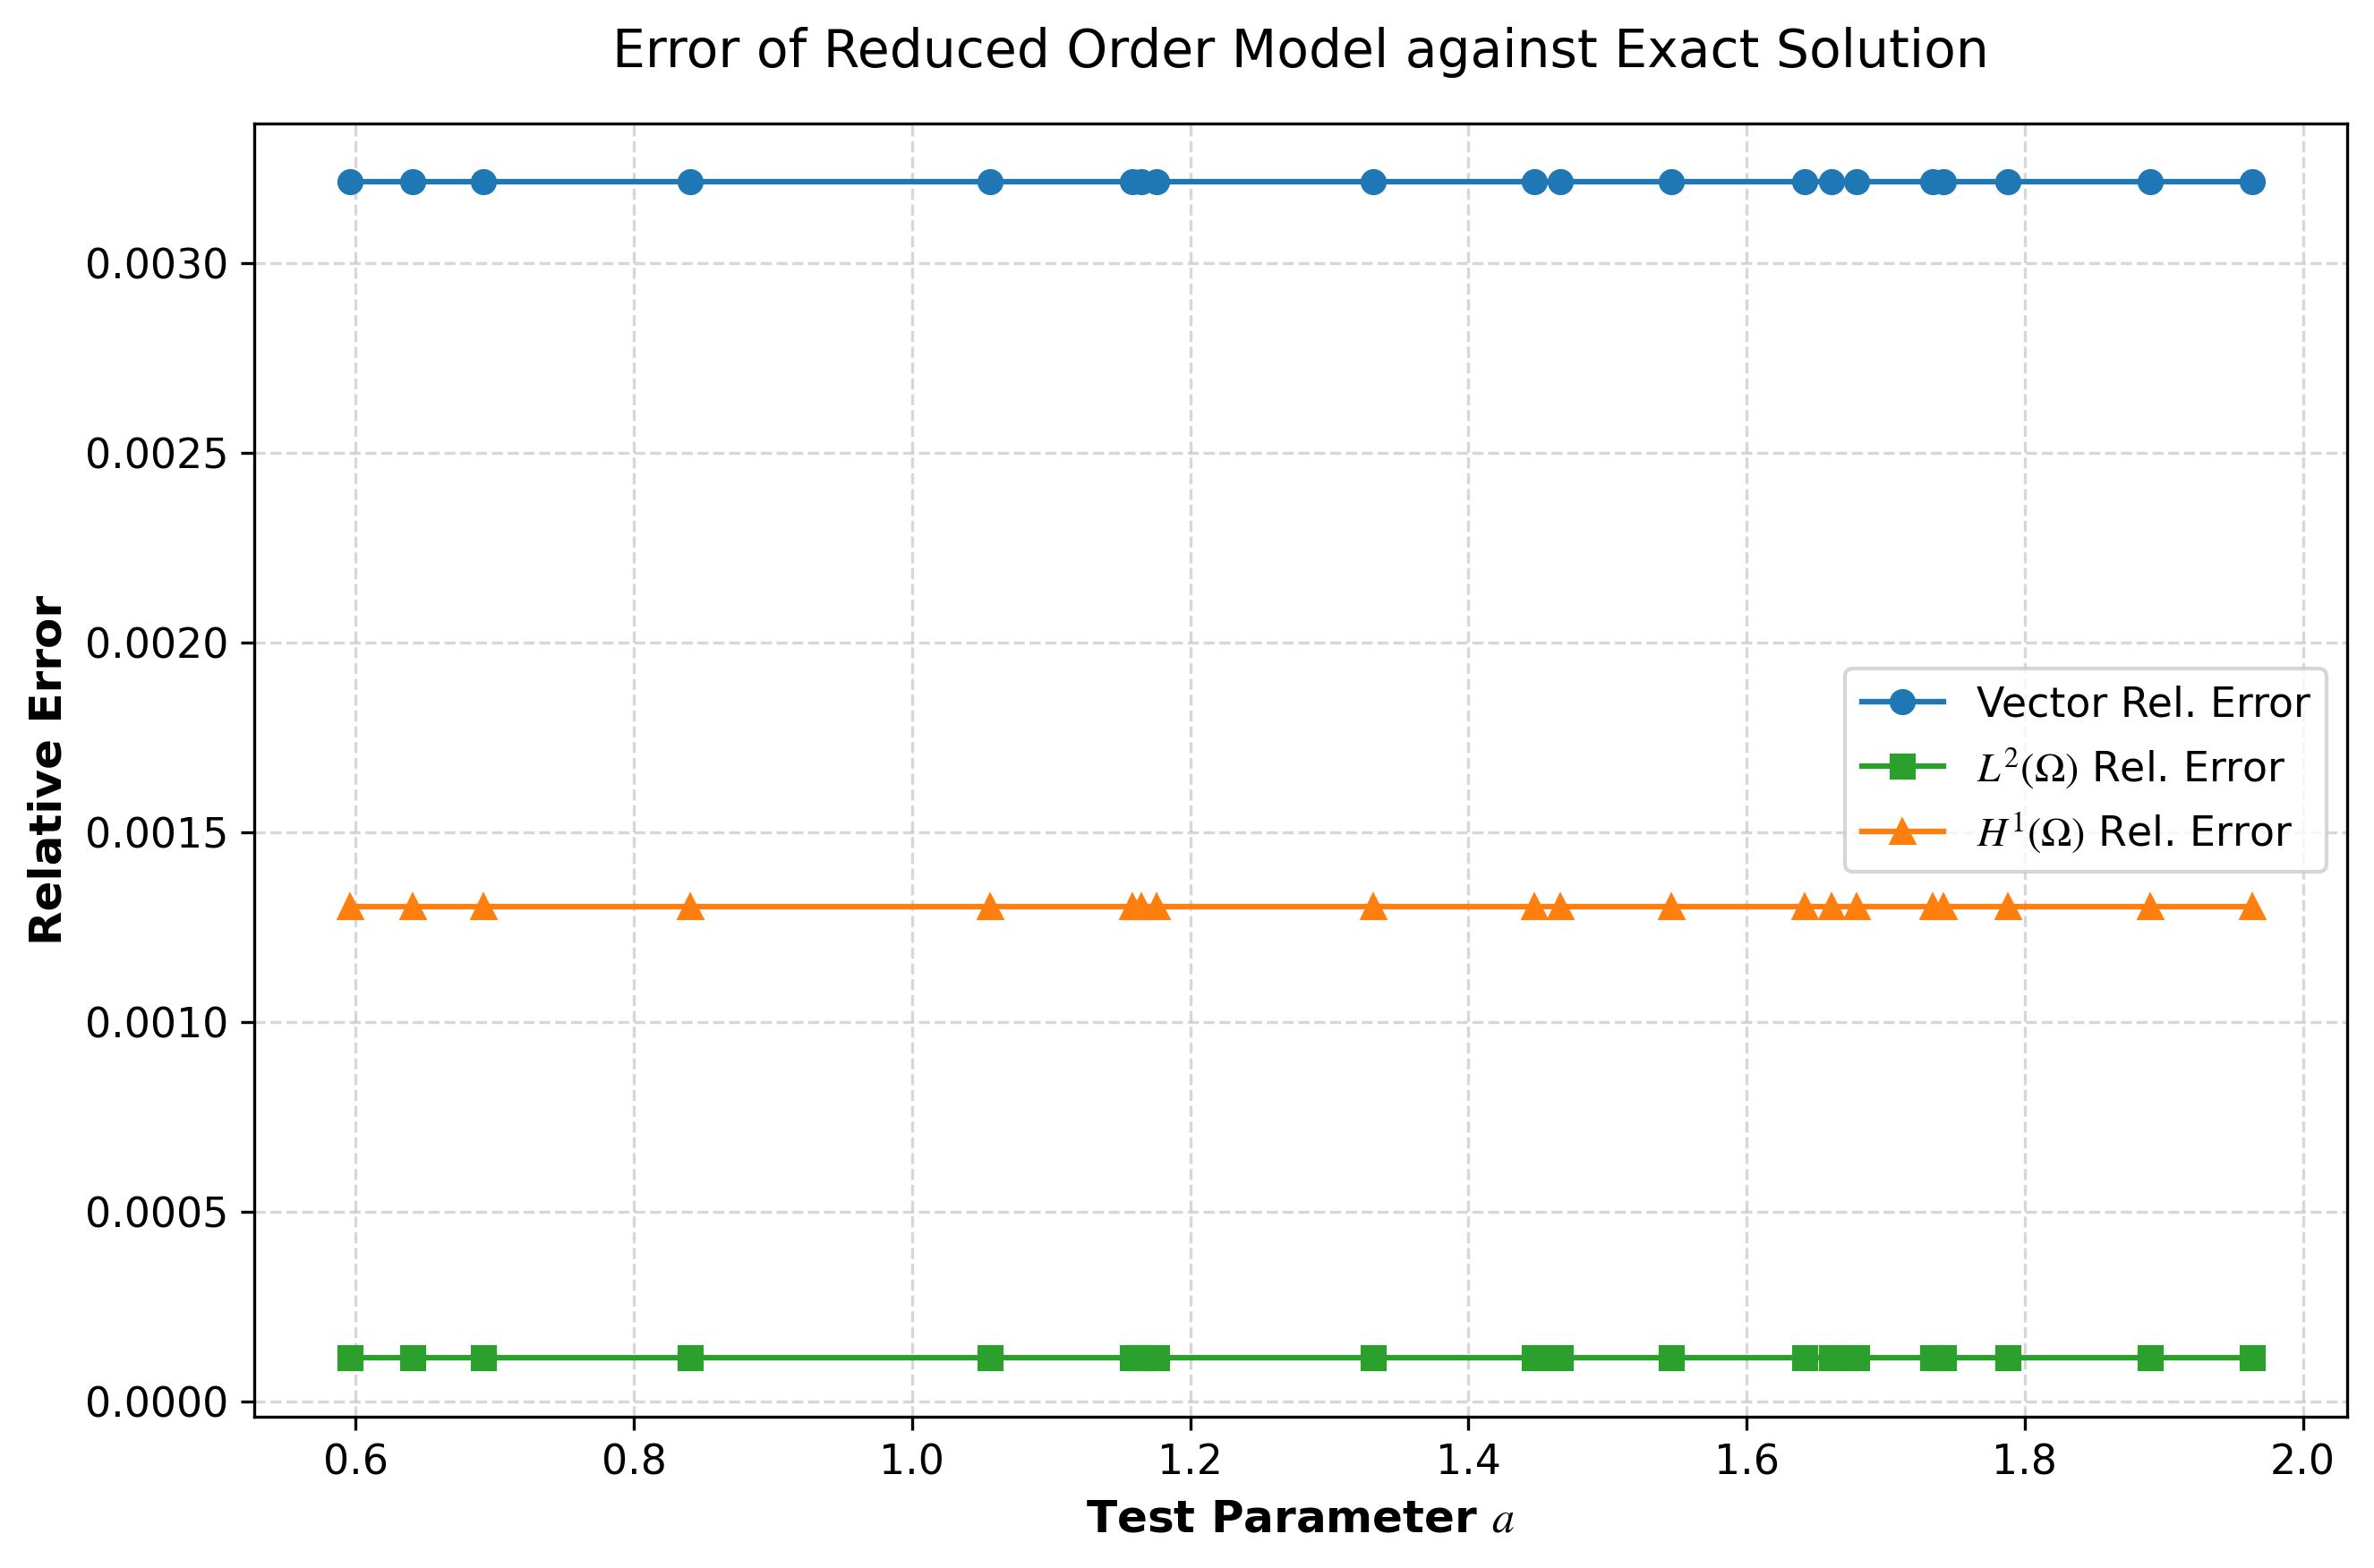

In [34]:
plt.figure(figsize=(9, 6))
plt.plot(test_a, test_vec_errors, marker='o', color='tab:blue', label='Vector Rel. Error', linewidth=1.5)
plt.plot(test_a, test_l2_errors, marker='s', color='tab:green', label='$L^2(\Omega)$ Rel. Error', linewidth=1.5)
plt.plot(test_a, test_h1_errors, marker='^', color='tab:orange', label='$H^1(\Omega)$ Rel. Error', linewidth=1.5)
plt.xlabel("Test Parameter $a$", fontweight='bold')
plt.ylabel("Relative Error", fontweight='bold')
plt.title("Error of Reduced Order Model against Exact Solution", pad=15)
# 若误差跨度较大，可以使用对数坐标
# plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "test_errors_vs_a.pdf"), bbox_inches="tight")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

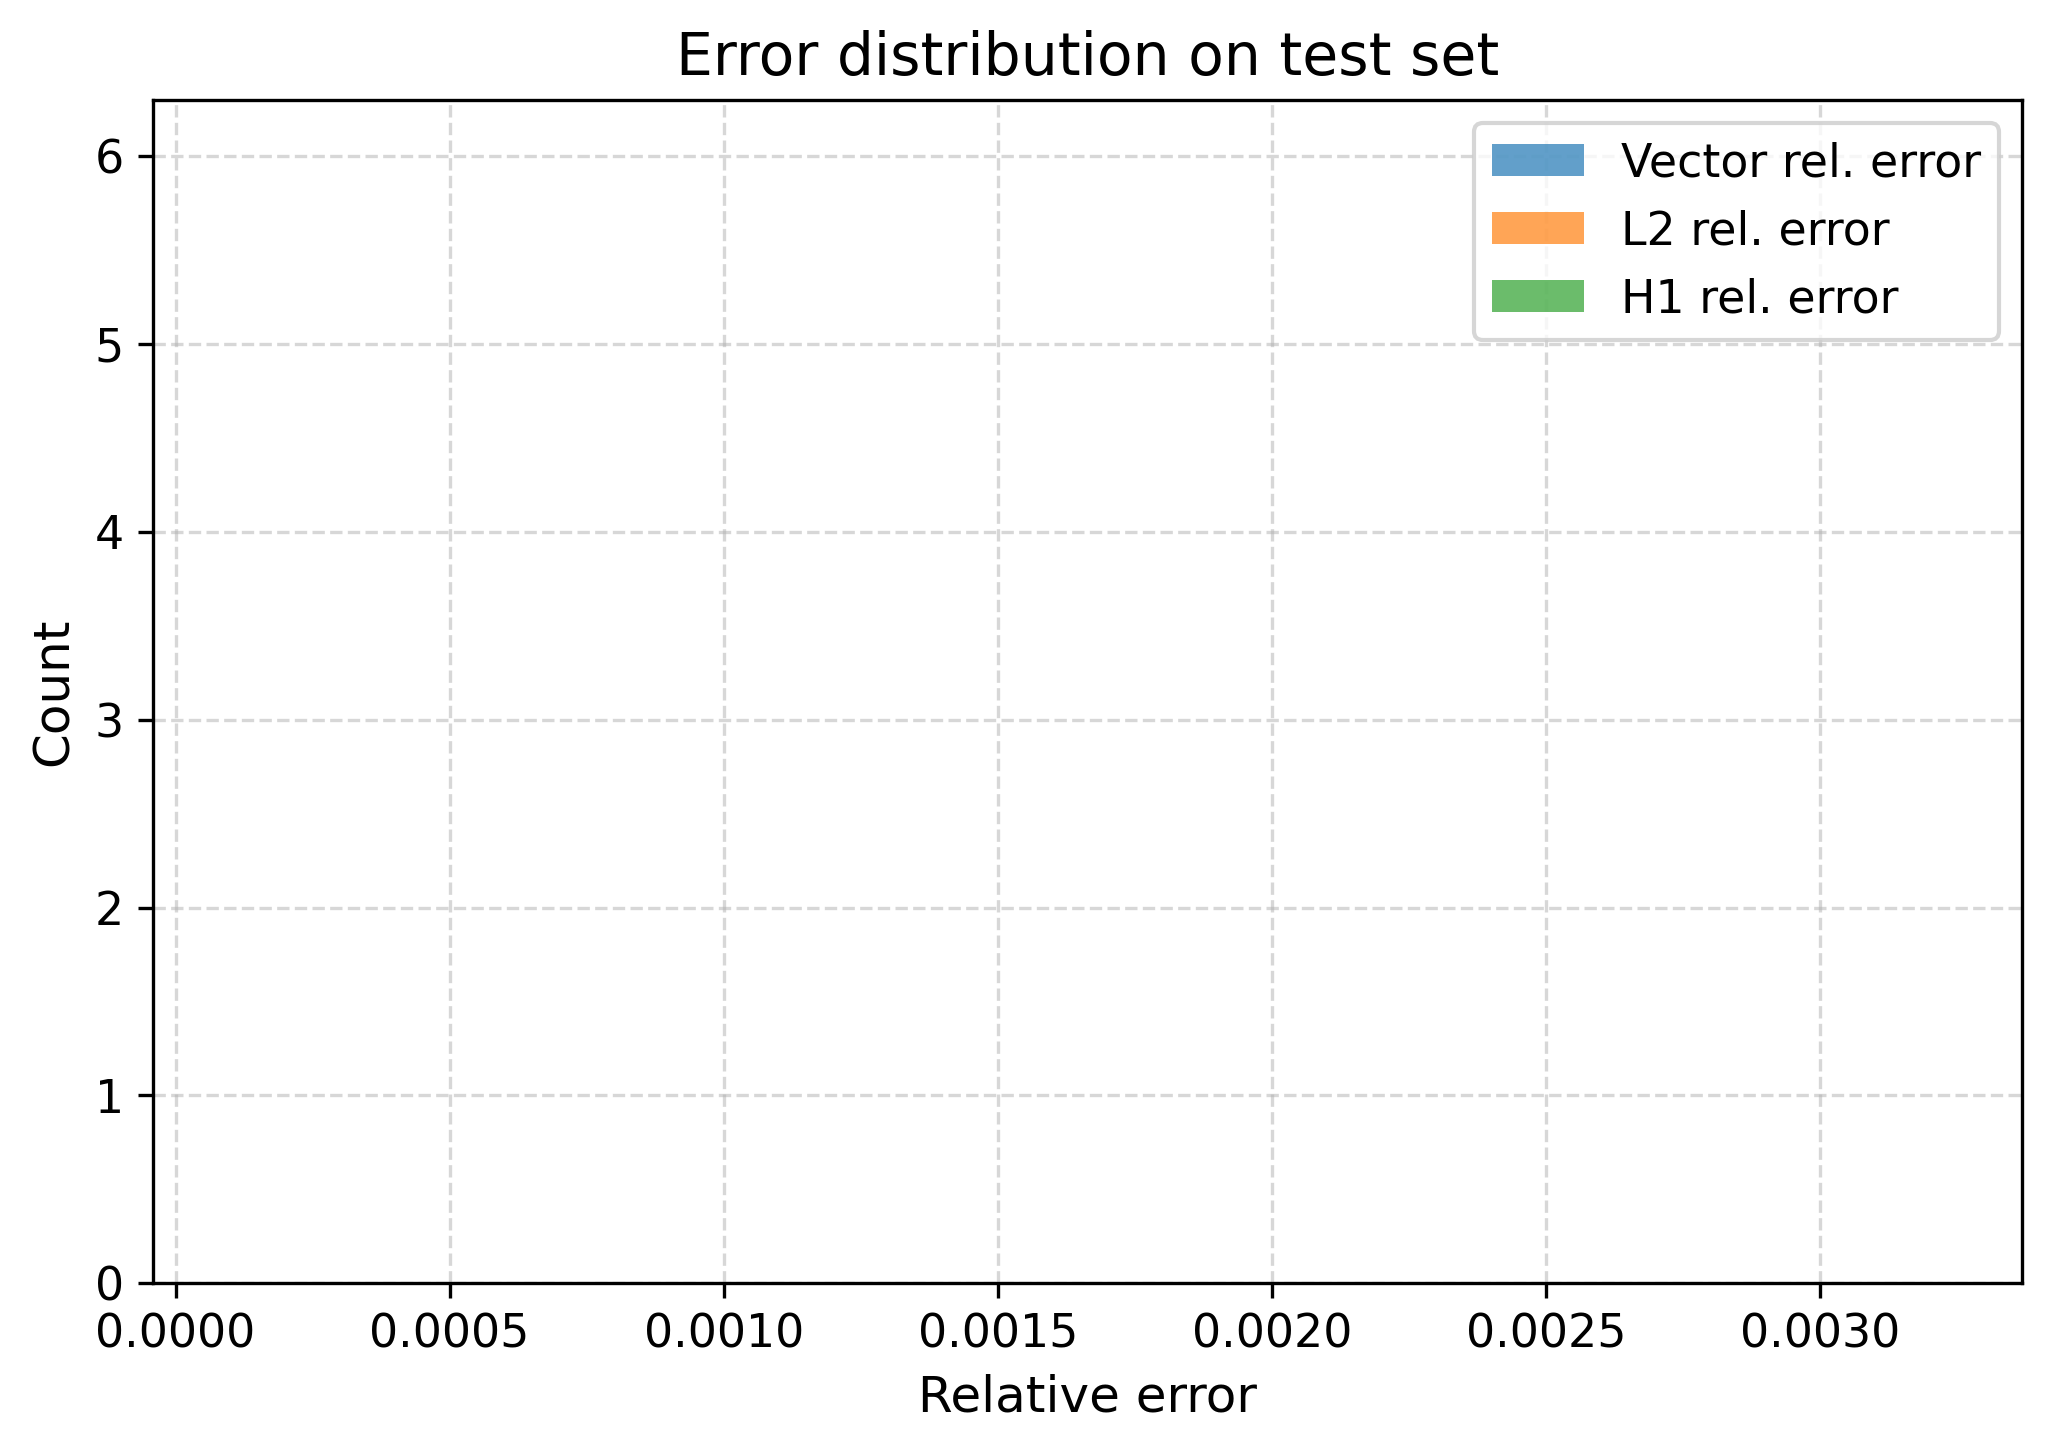

In [35]:

plt.figure(figsize=(7,5))
plt.hist(test_vec_errors, bins=10, alpha=0.7, label='Vector rel. error')
plt.hist(test_l2_errors, bins=10, alpha=0.7, label='L2 rel. error')
plt.hist(test_h1_errors, bins=10, alpha=0.7, label='H1 rel. error')
plt.xlabel("Relative error")
plt.ylabel("Count")
plt.title("Error distribution on test set")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "test_error_hist.png"), dpi=200, bbox_inches="tight")
plt.show()



## 单个测试样本的场对比

这里取一个测试参数，把降阶解和精确解做可视化对比。


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

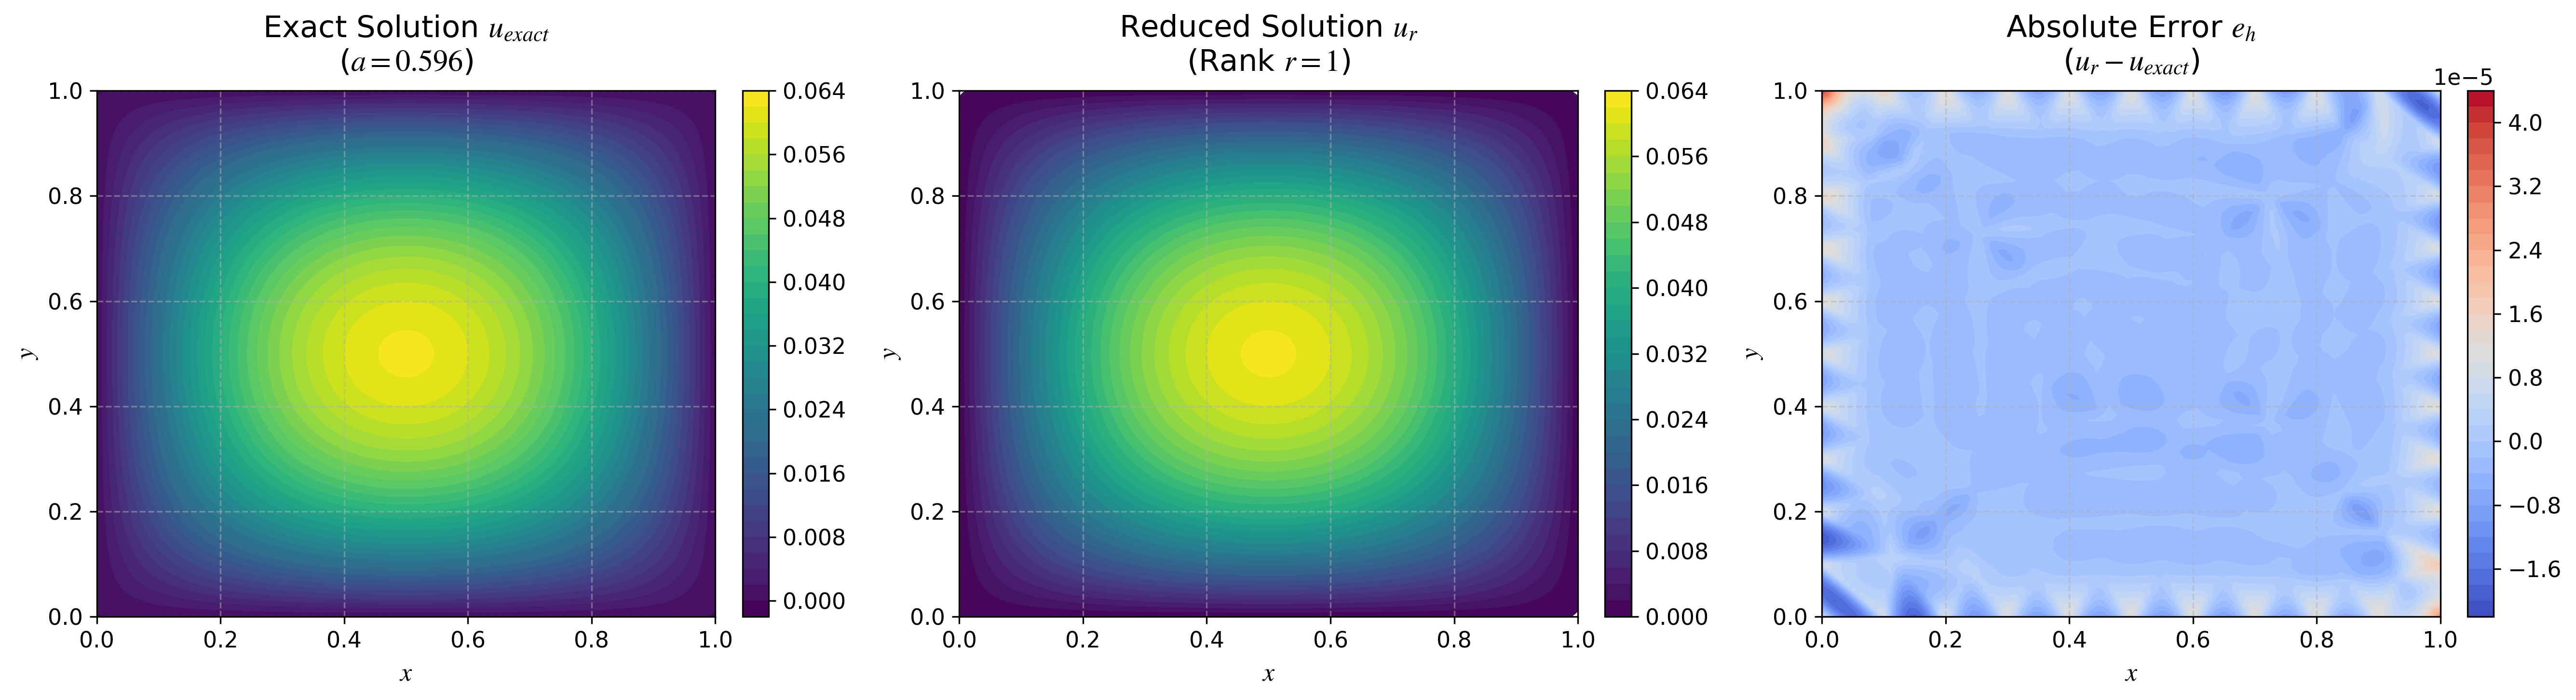

In [36]:
vis_idx = min(TEST_VIS_INDEX, NUM_TEST - 1)
a_vis = float(test_a[vis_idx])
_, vec_vis = rom.reduced_solve(a_vis, Phi)

exact_vis = rom.exact_gridfunction()
red_vis = rom.vector_to_gridfunction(vec_vis)
err_vis = rom.vector_to_gridfunction(vec_vis - exact_vec)

fig = plt.figure(figsize=(18, 5))

# 定义三个场与对应的标题
fields_to_plot = [
    (exact_vis, f"Exact Solution $u_{{exact}}$\n($a={a_vis:.3f}$)"),
    (red_vis, f"Reduced Solution $u_{{r}}$\n(Rank $r={rank_used}$)"),
    (err_vis, f"Absolute Error $e_{{h}}$\n($u_{{r}} - u_{{exact}}$)")
]

xs = np.linspace(0, 1, 100)
ys = np.linspace(0, 1, 100)

for i, (gfu, title) in enumerate(fields_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    Z = np.zeros((len(ys), len(xs)))
    for iy, yy in enumerate(ys):
        for ix, xx in enumerate(xs):
            Z[iy, ix] = gfu(mesh(xx, yy))
    
    # 采用更美观的学术渐变色谱 `viridis`，对于误差使用可双向对比的 `RdBu_r` 或 `coolwarm`
    cmap = 'coolwarm' if i == 2 else 'viridis'
    
    im = ax.contourf(xs, ys, Z, levels=40, cmap=cmap)
    ax.set_title(title, pad=10, fontsize=15)
    ax.set_xlabel('$x$', fontsize=13)
    ax.set_ylabel('$y$', fontsize=13)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if i == 2:
        cbar.formatter.set_powerlimits((0, 0)) # 科学计数法显示微小误差格式

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "field_comparison.pdf"), bbox_inches="tight")
plt.show()